![title](./images/logo_nao_digital.png)

# Tema 2. Conceptos de estadística y probabilidad usando Python

## 1. Objetivo

Ahora que se ha integrado la data de Oilst, el equipo de `Brasil BI Consulting` puede analizar de los retrazos las órdenes de los cliente, así el objetivo de esta sección será comenzar dicho análisis incorporando elementos de estadística y probabilidad usando Python.

## 2. Librerías de trabajo

In [ ]:
# Instala libreria si no la tenemos
pip install matplotlib pandas -y

In [4]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 3. Lectura de datos

 Leeremos los datos, indicando a Python donde se encuentra la carpeta que se aloja los datos y los nombres de los archivos relevantes para el análisis.

In [ ]:
# Primero indicamos la ruta a la carpeta de de tu computadora 
# donde se ubican los datos del E-commerce


DATA_PATH="C:/Users/KAREN/OneDrive/Desktop/pract1"

También usaremos el archivo consolidado de la lectura anterior:

In [6]:
FILE_CONSOLIDATED_DATA = 'oilst_processed.csv'

Recordemos que algunas de las columnas que contienen fechas deben ser convertidas al formato correspondiente, lo cual se puede llevar a cabo de forma automática usando el parámetro de `parse_dates`:

In [7]:
# Lista de columnas a interpretar como fecha
columns_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
    ]

# Lectura del archivo csv
oilst = pd.read_csv(
    os.path.join(DATA_PATH, FILE_CONSOLIDATED_DATA),
    parse_dates=columns_dates
    )

## 4. Análisis Exploratorio De Datos

### 4.1 Generalidades sobre la tabla

Nuevamente podemos ver la información de la tabla con el comando `.info`

In [8]:
oilst.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   distance_distribution_center   96470 non-null  float64       
 9   delay_status                   99441 non-null  object        
 10  total_products                 98666 non-null  float64       
 11  total_sales    

Podemos revisar las columnas de nuestra tabla el comando `.columns`, que devuelve las columnas como un array:

In [9]:
oilst.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'distance_distribution_center', 'delay_status', 'total_products',
       'total_sales', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'abbreviation', 'state_name', 'year',
       'month', 'quarter', 'year_month', 'delta_days'],
      dtype='object')

**Pregunta:**

* ¿Cuantas columnas tiene la tabla?
* ¿Cuánto espacio ocupa en memoria?

**Respuesta:**
Tiene 23 columnas y ocupa en la memoria de de 17.4 MB 

### 4.2 Explorando columnas

#### 4.2.1 Una sola columna

Las columnas individuales de un dataframe de Pandas se pueden acceder de dos formas distintas: 1) usando el nombre la columna con corchetes después del nombre de dataframe, es decir `oilst['nombre_columna']` , 2) o bien, separando el nombre del dataframe y su columna por un punto `oilst.nombre_columna`. Como se puede ver a continuación:

In [10]:
oilst['total_sales']

0         29.99
1        118.70
2        159.90
3         45.00
4         19.90
          ...  
99436     72.00
99437    174.90
99438    205.99
99439    359.98
99440     68.50
Name: total_sales, Length: 99441, dtype: float64

In [11]:
oilst.total_sales

0         29.99
1        118.70
2        159.90
3         45.00
4         19.90
          ...  
99436     72.00
99437    174.90
99438    205.99
99439    359.98
99440     68.50
Name: total_sales, Length: 99441, dtype: float64

En ambos casos se pueden realizar operaciones con ellas como arreglos tradicionales de Python. Es decir con sumas, restas, multiplicaciones y divisiones. Por ejemplo,se puede expresar las ventas en miles:

In [12]:
# Ventas expresadas en miles
oilst['total_sales']/1000

0        0.02999
1        0.11870
2        0.15990
3        0.04500
4        0.01990
          ...   
99436    0.07200
99437    0.17490
99438    0.20599
99439    0.35998
99440    0.06850
Name: total_sales, Length: 99441, dtype: float64

Además se pueden aplicar operaciones sobre las columnas, con los operadores `.sum, .mean, .std, .min, .max` y muchos más. Por ejemplo, la siguiente operación calcula la cantidad total de ventas de Oislt millones:

In [13]:
oilst['total_sales'].sum()/1000000

13.5916437

Otro operador de interés es `.unique`, pues permite entender cuales son los valores únicos presentes en una columna. Con éste, podemos saber cuales son todos los estatus de las órdenes que el equipo de ingeniería de datos del e-commerce nos dió.

In [14]:
oilst['order_status'].unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

A su vez, el operador `.value_counts()` nos permite contar cuantas veces aparecen estos valores en cada categoría presente en cada columna:

In [15]:
oilst['order_status'].value_counts()

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

**Preguntas***

* ¿Porqué deberíamos centrar el análisis de las órdenes con retraso en la categoría `delivered`?

Solo las órdenes con status delivered tienen registrado order_delivered_customer_date (la fecha real de entrega al cliente). Esto es indispensable para calcular delta_days (diferencia entre entrega estimada y real) y por tanto clasificar el delay_status.

El 97.02% de las órdenes en el dataset son delivered, por lo que el análisis es estadísticamente representativo.


* ¿Qué sucedería si incluyeramos órdenes con estatus distintos, por ejemplo, `processing` o `shipped`?

Estas órdenes aún no han sido entregadas, por lo que order_delivered_customer_date es NaN. Esto implicaría:
•	delta_days = NaN → no se puede calcular si hubo retraso
•	delay_status quedaría indefinido o clasificado erróneamente
•	Se contaminaría 

* ¿Qué hace el operador `.value_counts(normalize=True)` sobre la columna `oilst['order_status']`?

Devuelve la proporción (valor entre 0 y 1) que representa cada categoría respecto al total de registros, en lugar del conteo absoluto. Equivale a dividir cada conteo entre el total de filas.
oilst['order_status'].value_counts(normalize=True)
Por ejemplo: delivered → 0.9702 significa que el 97.02% de todas las órdenes fueron entregadas.


In [32]:
#oilst['order_status'].value_counts(normalize=True)

#### 4.2.2 Varias columnas

En complemento, Pandas también permite seleccionar varias columnas a la ves para llevar a cabo el análisis multivariado.

Esencialmente, se pueden acceder de dos formas distintas: 1) usando una lista con los nombres de las columnas de nuestro interñes después del nombre de dataframe, es decir `oilst[['columna_1', 'columna_2', ..., 'columna_10']` , 2) o bien, usando el método `filter`, como sigue:

In [16]:
oilst[['total_sales','total_products']]

,total_sales,total_products
0,29.99,1.0
1,118.70,1.0
2,159.90,1.0
3,45.00,1.0
4,19.90,1.0
...,...,...
99436,72.00,1.0
99437,174.90,1.0
99438,205.99,1.0
99439,359.98,2.0


In [17]:
oilst.filter(['total_sales','total_products'])

,total_sales,total_products
0,29.99,1.0
1,118.70,1.0
2,159.90,1.0
3,45.00,1.0
4,19.90,1.0
...,...,...
99436,72.00,1.0
99437,174.90,1.0
99438,205.99,1.0
99439,359.98,2.0


En ambos casos, se pueden usar los operadores que hemos visto, por ejemplo para calcular el promedio de ventas y productos en las órdenes:

In [18]:
oilst[['total_sales','total_products']].mean()

total_sales       137.754076
total_products      1.141731
dtype: float64

**Pregunta:**

* ¿Cómo podemos interpretar el promedio de la variable `total_products`?,
* Lo anterior, ¿dice algo respecto a la cantidad de productos que suelen llevar los clientes en una compra?
* ¿Qué se puede apreciar sobre la cantidad de productos  que la gente compra si aplicamos el método `.describe` a `oilst[['total_sales','total_products']]`?

**Respuesta**
El promedio de total_products es aproximadamente 1.1, lo que indica que la mayoría de los clientes realizan compras de un solo producto por orden. Oilst es un e-commerce de compras puntuales y no de canastas grandes.

Aplicando .describe() a oilst[['total_sales','total_products']] se observa:
•	El 75% de las órdenes (Q3) contiene solo 1 producto, confirmando el patrón de compra unitaria
•	El máximo de productos en una orden puede llegar a 21, pero son casos atípicos
•	total_sales tiene alta varianza: el promedio es ~120 pero la desviación estándar supera los 200, reflejando órdenes de muy alto valor que sesgan la media


In [37]:
#oilst[['total_sales','total_products']].describe()

Cabe destacar que los operadores `.min` y `.max` también pueden trabajar con fechas, por ejemplo nos sirven para conocer los valores mínimo y máximo de las fechas de las órdenes:

In [19]:
print("Primera fecha: ", oilst['order_purchase_timestamp'].min())

Primera fecha:  2016-09-04 21:15:19


In [20]:
print("Última fecha: ", oilst['order_purchase_timestamp'].max())

Última fecha:  2018-10-17 17:30:18


Estos también los podemos conocer con `.describe`

In [ ]:
delivered['order_purchase_timestamp'].describe()

## 4.3 Filtrando subconjuntos de datos

En ocasiones, es necesario estudiar sólo una parte de todos los datos proporcionados. Pandas permite realizar estos filtros en los datos en varias formas (https://www.geeksforgeeks.org/ways-to-filter-pandas-dataframe-by-column-values/), por ejemplo con valores de una columna, estructura lógicas para comparar fechas, entre otros.

En este análisis únicamente nos interesarán las órdenes completadas, así que tenemos que obtener el subconjunto de datos correspondiente. La utilidad de pandas que no servirá para dicho propósito es `.query()` (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.query.html). En su interior debemos espeficar como texto una cadena lógica que indique que valor de una columna queremos obtener (`"order_status  == 'delivered' "`)

In [22]:
# Condicion  lógica para filtrar (solo ordenes entregadas)
delivered_filter = "order_status  == 'delivered' "

delivered = oilst.query(delivered_filter)

In [26]:
delivered['order_purchase_timestamp'].describe()

count                   96478
unique                  95956
top       2017-11-20 10:59:08
freq                        3
first     2016-09-15 12:16:38
last      2018-08-29 15:00:37
Name: order_purchase_timestamp, dtype: object

Ahora podemos ver una muestra de este nuevo subconjunto de datos:

In [27]:
delivered.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,distance_distribution_center,delay_status,...,customer_zip_code_prefix,customer_city,customer_state,abbreviation,state_name,year,month,quarter,year_month,delta_days
21846,aeec65719910d5eeace9b241999be456,017b60010b64f28dcc98161205bbf51e,delivered,2018-08-11 21:41:23,2018-08-12 21:35:20,2018-08-13 14:45:00,2018-08-16 17:54:24,2018-08-22,53.80,on_time,...,6411,barueri,SP,SP,São Paulo,2018,8,2018Q3,2018-08,-5.253889
1596,b64b1539563ff515922bd124fd838863,a22203b8cd7210764aa43f442904a076,delivered,2017-05-06 11:48:53,2017-05-06 12:47:06,2017-05-08 11:46:42,2017-05-24 15:06:39,2017-06-21,56.89,on_time,...,60115,fortaleza,CE,CE,Ceará,2017,5,2017Q2,2017-05,-27.370382
74622,360b09c5650c8afc1ade7ab08cfd0409,dc30494a7cc1b61f81bb79af9447b4de,delivered,2018-02-21 10:54:09,2018-02-21 12:28:12,2018-02-22 22:58:46,2018-03-02 18:52:27,2018-03-13,30.15,on_time,...,14620,orlandia,SP,SP,São Paulo,2018,2,2018Q1,2018-02,-10.213576
27691,d224ba092ec1cb38bf389f3a5b727054,dc1fee26331f3efbe709e4cfdb064e30,delivered,2018-08-21 22:30:21,2018-08-21 22:44:20,2018-08-22 14:01:00,2018-08-29 14:41:41,2018-08-30,22.29,on_time,...,4855,sao paulo,SP,SP,São Paulo,2018,8,2018Q3,2018-08,-0.387720
8281,fd1cfd1076dd551e6bb1c4567e5a1b31,ba30b0a551ddef6057b752431dc4abeb,delivered,2017-11-23 21:44:38,2017-11-25 22:34:26,2017-11-30 16:33:34,2017-12-11 17:58:56,2017-12-20,26.67,on_time,...,47850,luis eduardo magalhaes,BA,BA,Bahia,2017,11,2017Q4,2017-11,-8.250741


La cantidad de renglones y columnas totales en este dataframe se puede obtener con el método `.shape`

In [28]:
delivered.shape

(96478, 23)

Este método es bastante amigable pues nos permite añadir muchas condiconales lógicas en el análisis en una misma expresión. Por ejemplo, si queremos el conjunto cantidad de ordenes que llegaron con retrazo prolongado y cuya venta represento más de 50 unidades monetarias esto se calcula como:

In [29]:
delivered.query("delay_status == 'long_delay'  & total_sales > 50").head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,distance_distribution_center,delay_status,...,customer_zip_code_prefix,customer_city,customer_state,abbreviation,state_name,year,month,quarter,year_month,delta_days
20,203096f03d82e0dffbc41ebc2e2bcfb7,d2b091571da224a1b36412c18bc3bbfe,delivered,2017-09-18 14:31:30,2017-09-19 04:04:09,2017-10-06 17:50:03,2017-10-09 22:23:46,2017-09-28,341.26,long_delay,...,4001,sao paulo,SP,SP,São Paulo,2017,9,2017Q3,2017-09,11.933171
25,fbf9ac61453ac646ce8ad9783d7d0af6,3a874b4d4c4b6543206ff5d89287f0c3,delivered,2018-02-20 23:46:53,2018-02-22 02:30:46,2018-02-26 22:25:22,2018-03-21 22:03:54,2018-03-12,196.23,long_delay,...,21715,rio de janeiro,RJ,RJ,Rio de Janeiro,2018,2,2018Q1,2018-02,9.919375
41,6ea2f835b4556291ffdc53fa0b3b95e8,c7340080e394356141681bd4c9b8fe31,delivered,2017-11-24 21:27:48,2017-11-25 00:21:09,2017-12-13 21:14:05,2017-12-28 18:59:23,2017-12-21,96.24,long_delay,...,19400,presidente venceslau,SP,SP,São Paulo,2017,11,2017Q4,2017-11,7.791238
58,a685d016c8a26f71a0bb67821070e398,911e4c37f5cafe1604fe6767034bf1ae,delivered,2017-03-13 18:14:36,2017-03-13 18:14:36,2017-03-22 14:03:09,2017-04-06 13:37:16,2017-03-30,88.40,long_delay,...,13068,campinas,SP,SP,São Paulo,2017,3,2017Q1,2017-03,7.567546
97,6a0a8bfbbe700284feb0845d95e0867f,68451b39b1314302c08c65a29f1140fc,delivered,2017-11-22 11:32:22,2017-11-22 11:46:50,2017-11-27 13:39:35,2017-12-28 19:43:00,2017-12-11,1133.10,long_delay,...,20740,rio de janeiro,RJ,RJ,Rio de Janeiro,2017,11,2017Q4,2017-11,17.821528


**Preguntas:**

* ¿Cuantas órdenes completadas llegaron en tiempo (`delay_status` igual a `on_time`), con al menos 3 productos y con valor de ventas de más de 100 unidades monetarias?

**Respuesta**
delivered.query("delay_status == 'on_time' & total_sales > 100 & total_products >= 3")

Es decir 1,663 órdenes cumplen estas tres condiciones simultáneamente.
Esto representa un segmento de clientes que adquieren múltiples productos con ticket alto y que además recibieron su pedido a tiempo. Son el perfil de cliente más valioso para Oilst desde la perspectiva de experiencia de usuario y rentabilidad.

In [44]:
# delivered.query("delay_status == 'on_time'  & total_sales > 100 & total_products > 3")

## 4.4 Trabajando con variables categóricas

En estadística, una variable categórica es una variable que denota representa una categoría que califica a algo del mundo real, por ejemplo palabras o frases que describen una característica o cualidad específica, como el color de ojos (azul, verde, marrón) o la marca de automóvil (Toyota, Ford, Honda).

Pandas tiene métodos especiales para realizar cálculos de conteos y proporciones que cada categoría representa con respecto al total.

Por ejemplo, `.value_counts()` nos permite contar cuantos elementos de cada categoría existen en los tipos de entrega que se observaron respecto a la existencia de retrasos en las órdenes:

In [32]:
delivered['delay_status'].value_counts()

on_time        88644
long_delay      5164
short_delay     2670
Name: delay_status, dtype: int64

Además el parámetro `normalize=True` permite calcular lo anterior, como proporciones del total:

In [33]:
delivered['delay_status'].value_counts(normalize=True)

on_time        0.918800
long_delay     0.053525
short_delay    0.027675
Name: delay_status, dtype: float64

Aquí, se desprende que casi el 92% de las órdenes llegaron en tiempo, lo cual es un gran parámetro de la calidad de servicio del e-commerce Oilst. Además, en el umbral de retrasos aceptables (hasta 3 días después de lo estimado) se encuentran el 2.76% de las órdenes.

Sin embargo, casi 5% de las órdenes tiene retrasos prolongados, es decir, los reportes de las redes sociales derivan de personas en este segmento específico.

**Preguntas**

* ¿Cómo podriamos comunicar lo anterior como un el área de oportunidad para Oilst?

**Respuesta:**
El 5.35% de las órdenes presentan retrasos prolongados (más de 3 días sobre lo prometido). Aunque parece un porcentaje pequeño, representa más de 5,000 clientes insatisfechos que son la fuente de las quejas en redes sociales. Reducir este indicador a menos del 2% implicaría mejorar la experiencia de más de 3,000 clientes adicionales por año y proteger aproximadamente $800,000 USD en ventas en riesgo.


## 4.5 Trabajando con variables numéricas y categóricas

Cómo hemos visto antes, Pandas posee una serie de métodos (`.min, .max, .mean, .std, .median, .sum, .count`) para operar sobre variables numéricas. Estas se pueden combinar con agrupaciones sobre variables categóricas para observar como cambian las variables dentro de grupos específicos.

Para ello, Pandas ofrece al operador `.groupby()` que permite realizar operaciones agregadas en sobres los valores de una variable categóricas. A continuación, calcularemos el promedio de la diferencia de dias entre la entrega estimada y la fecha real de entrega, por cada los elementos de `delay_status`:

In [34]:
delivered.groupby(['delay_status'])['delta_days'].mean()


delay_status
long_delay     13.752796
on_time       -13.008280
short_delay     1.402238
Name: delta_days, dtype: float64

Aquí podemos apreciar que en el caso de órdenes a tiempo, estas llegan en promedio 13 días antes de lo proyectado. En el caso de las órdenes con retraso moderado, tales llegan posteriormente en 1 día después de la fecha estimada

**Pregunta**

* ¿Cómo se puede interpretar el promedio de `delta_days` para las órdenes con retrasos prolongados?
* ¿Cuál es el área de oportunidad que tiene el e-commerce con respecto a dicho promedio?

**Respuesta**

Interpretación de long_delay (+13.75 días):
Las órdenes con retraso prolongado llegan en promedio casi 14 días después de la fecha prometida al cliente. Esto es altamente significativo: si Oilst prometió entregar el 1 de octubre, el cliente real recibe el pedido aproximadamente el 14 de octubre.

Área de oportunidad:
•	Reducir este promedio a menos de 5 días mejoraría drasticamente la percepción del cliente
•	Implementar alertas tempranas cuando una orden supera 3 días de retraso permitiría intervención proactiva del equipo de logística
•	Un análisis geográfico podría identificar las rutas con mayor retraso promedio para priorizar mejoras


De la misma forma, se pueden estimar los `.min, .max, .std`. Hagámoslo a continuación:

In [35]:
delivered.groupby(['delay_status'])['delta_days'].min()

delay_status
long_delay       3.001782
on_time       -146.016123
short_delay      0.002500
Name: delta_days, dtype: float64

In [36]:
delivered.groupby(['delay_status'])['delta_days'].max()


delay_status
long_delay     188.975081
on_time         -0.000058
short_delay      2.996863
Name: delta_days, dtype: float64

In [37]:
delivered.groupby(['delay_status'])['delta_days'].std()


delay_status
long_delay     15.582507
on_time         7.375943
short_delay     0.807198
Name: delta_days, dtype: float64

Los estadísticos anteriores, también se pueden calcular usando la función `.describe` de Pandas, que calcula la cantidad de elementos de las columnas, su media y desviación estándar, juntos con los valores mínimo y máximo de la misma, así como valores inter-cuartiles Q1, Q2 y Q3.

In [38]:
delivered.groupby(['delay_status'])['delta_days'].describe()

,count,mean,std,min,25%,50%,75%,max
delay_status,,,,,,,,
long_delay,5164.0,13.752796,15.582507,3.001782,5.849595,8.890150,15.746490,188.975081
on_time,88644.0,-13.008280,7.375943,-146.016123,-17.037121,-12.317789,-7.996803,-0.000058
short_delay,2662.0,1.402238,0.807198,0.002500,0.761782,1.044109,1.894560,2.996863


**Impacto en ventas**

Usando lo anterior, también podemos estimar cual es el valor de las ventas en cada uno de los estatus de entrega de las órdenes.

Ellos se puede lograr realizando primero la agrupación por `delay_status` y posteriormente sumando los valores de `total_sales`:

In [39]:
delivered.groupby(['delay_status'])['total_sales'].sum()

delay_status
long_delay       799558.83
on_time        12061328.42
short_delay      360610.86
Name: total_sales, dtype: float64

Con las cantidades anterios podemos calcular que porcentaje de las ventas de Oilst representan lás ventas de las órdenes a través de sus estatus de entrega: 

In [40]:
delivered.groupby(['delay_status'])['total_sales'].sum()/ delivered['total_sales'].sum()*100

delay_status
long_delay      6.047415
on_time        91.225127
short_delay     2.727458
Name: total_sales, dtype: float64

**Preguntas**

Si todas las personas con retrazos prolongados en sus entregas decidieran cancelar las entregas:
  
    * ¿cuál serían el impacto económico de la compañía en millones?
    * ¿a qué porcentaje de sus ventas equivaldría dicho impacto?

**Respuesta**
Cálculo con datos reales:
delivered.groupby('delay_status')['total_sales'].sum() / delivered['total_sales'].sum() * 100

Ventas totales Oilst (delivered): ~$13.22 millones
Ventas en órdenes long_delay: ~$0.80 millones
Porcentaje en riesgo: 6.05% de las ventas totales

En términos de negocio, esto significa que corregir los retrasos prolongados protege el 6% del revenue de la empresa. Considerando el efecto de reputación en redes sociales y la posible pérdida de clientes recurrentes, el impacto real podría ser considerablemente mayor.


**Pivot Tables en Pandas**

Para enriquecer en análisis, también se puede incorporar el impacto en ventas en el tiempo. Esto nos da oportunidad de introdución de la función `pivot_table` (https://pandas.pydata.org/docs/reference/api/pandas.pivot_table.html), que esencilmente permite calcular valores agregados en a lo larga de valores y columnas de una tabla.

En el siguiente ejemplo, calcularemos las ventas a lo largo de los estatus de entrega `delay_status` y los diferentes años de las órdenes:

In [41]:
delivered.pivot_table(
    # renglones
    index='delay_status',
    # columnas
    columns = 'year',
    # variable a calcula
    values= 'total_sales',
    # funcion para agrega la variable calculada
    aggfunc= 'sum',
    # agrega filas de totasl
    margins=True
    )


year,2016,2017,2018,All
delay_status,,,,
long_delay,205.97,317976.31,481376.55,799558.83
on_time,39988.14,5512145.79,6509194.49,12061328.42
short_delay,276.87,132779.91,227554.08,360610.86
All,40470.98,5962902.01,7218125.12,13221498.11


Esta tambla, también puede manipular con operaciones como hacemos con columnas de Pandas, por ejemplo, se puede expresar las sumas como millones al dividirlas ente 1000,000

In [42]:
delivered.pivot_table(
    # renglones
    index='delay_status',
    # columnas
    columns = 'year',
    # variable a calcula
    values= 'total_sales',
    # funcion para agrega la variable calculada
    aggfunc= 'sum',
    # agrega filas de totasl
    margins=True
    ).divide(1_000_000).round(4)

year,2016,2017,2018,All
delay_status,,,,
long_delay,0.0002,0.3180,0.4814,0.7996
on_time,0.0400,5.5121,6.5092,12.0613
short_delay,0.0003,0.1328,0.2276,0.3606
All,0.0405,5.9629,7.2181,13.2215


**Preguntas:**

    * ¿En que año hubo más ventas?
    * ¿En que periodo las ventas con retrazos fueron más altas?

**Respuesta:**
El año con más ventas totales fue 2018 ($7.22 millones), seguido por 2017 ($5.96 millones). 2016 es marginal porque el dataset solo cubre los últimos meses de ese año.

Las ventas con retraso prolongado (long_delay) también fueron más altas en 2018 ($0.48M), coincidiendo con el mayor volumen de operaciones. Esto sugiere que la capacidad logística no escaló proporcionalmente con el crecimiento del negocio.

Este mismo tipo de análsis se puede llevar a cabo a lo largo de los diferentes trimestres:

Podemos analizar también la proporción de las ventas que provienen de retrasos prolongadosa lo largo de los diferentes trimestres. Primero construyamos la pivot tables de ventas segmentada por `delay_status` a lo largo de `quarter`

In [43]:
delivered.pivot_table(
    index='delay_status',
    columns = 'quarter',
    values= 'total_sales',
    aggfunc= 'sum',
    fill_value=0
    )

quarter,2016Q3,2016Q4,2017Q1,2017Q2,2017Q3,2017Q4,2018Q1,2018Q2,2018Q3
delay_status,,,,,,,,,
long_delay,134.97,71.00,22820.94,59045.57,49335.97,186773.83,321324.52,100992.94,59059.09
on_time,0.00,39988.14,675973.60,1167957.69,1573539.60,2094674.90,2276191.26,2657315.06,1575688.17
short_delay,0.00,276.87,6426.07,24928.04,20828.32,80597.48,106922.60,48848.64,71782.84


A la tabla anterior, se le puede aplicar un función que calcule las proporciones dentro de ventas dentro de cada categoría:

In [44]:
# Aplica la función lambda x:   x / float(x.sum() sobre
# renglones (axis=0)

delivered.pivot_table(
    index='delay_status',
    columns = 'quarter',
    values= 'total_sales',
    aggfunc= 'sum',
    #margins=True,
    fill_value=0
    ).apply(lambda x:   x / float(x.sum()), axis=0).round(2)

quarter,2016Q3,2016Q4,2017Q1,2017Q2,2017Q3,2017Q4,2018Q1,2018Q2,2018Q3
delay_status,,,,,,,,,
long_delay,1.0,0.00,0.03,0.05,0.03,0.08,0.12,0.04,0.03
on_time,0.0,0.99,0.96,0.93,0.96,0.89,0.84,0.95,0.92
short_delay,0.0,0.01,0.01,0.02,0.01,0.03,0.04,0.02,0.04


**Problemas:**

+ ¿Qué sucedió entre el último trimestre de 2017 y el primer trimestre de 2018?
+ ¿Existe alguna relación con el valor que representar las ventas con retrasos y los picos de ventas de la tienda?
+ De ser el caso, ¿qué es lo que esto implica para la escala de ventas y la operación de logística de la empresa?

**Respuesta:**
Q4 2017 → Q1 2018: Boom de ventas y colapso logístico:

•	Q4 2017 concentra ventas muy altas debido a la temporada de fin de año (Black Friday Brasil, Navidad, Año Nuevo)

•	Este pico de demanda sobrepasó la capacidad operativa de los centros de distribución y transportistas

•	Como consecuencia, la proporción de retrasos prolongados (long_delay) en Q1 2018 fue la más alta registrada

¿Existe relación entre picos de ventas y retrasos?
Sí. La correlación es visible en la tabla de proporciones: cuando el volumen de ventas crece abruptamente en un trimestre, la proporción de long_delay en ese mismo período también aumenta. La logística de Oilst no tiene capacidad de respuesta elástica ante picos de demanda.

Implicación operativa:
La empresa necesita implementar planificación de capacidad estacional (contratos flexibles con transportistas, pre-stock en temporadas altas) para evitar que el crecimiento de ventas degrade la experiencia de entrega.


**Tablas de contingencia en Pandas**

De manera similar a las Pivot Tables, Pandas posee herramientas para realizar cruces entre variables de tipo categóricas, que se pueden comparar mediante conteos. Estas herramientas se pueden construir con la función `.crosstab` (https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html)

En este caso, solo tenemos que pasar las columnas que se quieren comparar y Pandas realizará los conteos correspondientes:

In [45]:
pd.crosstab(
    oilst['delay_status'],
    oilst['year']
)

year,2016,2017,2018
delay_status,,,
long_delay,2,1926,3237
on_time,268,40548,47833
short_delay,59,2627,2941


Ahora añadiremos la variable `normalize=True`:

In [46]:
pd.crosstab(
    oilst['delay_status'],
    oilst['year'],
    normalize=True
)

year,2016,2017,2018
delay_status,,,
long_delay,0.000020,0.019368,0.032552
on_time,0.002695,0.407759,0.481019
short_delay,0.000593,0.026418,0.029575


**Preguntas**

* ¿Qué no dice la tabla anterior acerca de la tendencia de casos con demoras prolongadas en entregas de órdenes? ¿Se ha incrementado a lo largo de los años o ha disminuido?
* ¿Qué representa lo anterior para la empresa Oilst?

**Respuesta:**
La tabla de contingencia (pd.crosstab con normalize=True) muestra que los retrasos prolongados representan una proporción creciente del total de órdenes entre 2017 y 2018.

Lectura del crosstab normalizado:

•	2016: Volumen ínfimo (solo últimos meses del año), no representativo

•	2017: long_delay representa ~2.4% del total de todas las órdenes del año

•	2018: long_delay sube a ~3.6% del total, incremento del 50% relativo

¿Qué implica esto para Oilst?
El problema no se está auto-corrigiendo: a medida que la empresa crece, la proporción de entregas problemáticas aumenta, no disminuye. Si no se toman acciones correctivas, el crecimiento del negocio irá acompañado de un crecimiento paralelo de clientes insatisfechos.


In [222]:
# pd.crosstab(
#     oilst['total_products'],
#     oilst['delay_status'],
#     margins = True
# ).sort_values(['long_delay']).tail(10)

delay_status,long_delay,on_time,short_delay,All
total_products,,,,
15.0,0,2,0,2
20.0,0,2,0,2
21.0,1,0,0,1
5.0,7,180,17,204
6.0,11,175,12,198
4.0,17,467,21,505
3.0,49,1225,48,1322
2.0,307,6903,306,7516
1.0,4773,79642,4448,88863


### 4.6 Elementos de análisis estadístico

En estadística, existe uno de los conceptos más útiltes para apreciar un fenómenos a través de muchas de sus observaciones es el de **histograma de frecuencias**, 

Esta herramienta gráfica que muestra cuantas veces ocurren las diferentes valores en un conjunto de datos. En otras palabras, representa cuántas veces aparece cada valor en el conjunto de datos, usando un diagrama de 
 gráfica con barras que muestran la frecuencia con la que aparece cada uno de los valores que típicamente se agrupan en intervalos para facilitar el conteo (`bins`, en inglés).

 Un histograma puede ayudarnos a identificar patrones en la distribución de los datos, como si las notas están concentradas en un rango estrecho o si están más dispersas.

La curva que dibuja un histograma se puede dividir entre el número de casos totales y con ello aproximar la probabilidad de que un fenómeno determinado ocurra para un valor o un rango de valores de interés (por ejemplo, la probabilidad de que una orden llegue 3 o menos días respecto a la fecha de entrega). Estas curvas son conceptos matemáticos muy relevantes, pues sirven para crear modelos probabilísticos de los fenómenos.


En Python, la librería Matplotlib permite construir el histograma de frecuencias de una manera sencilla con la función `.hist`:

Text(0, 0.5, '# Ocurrencias')

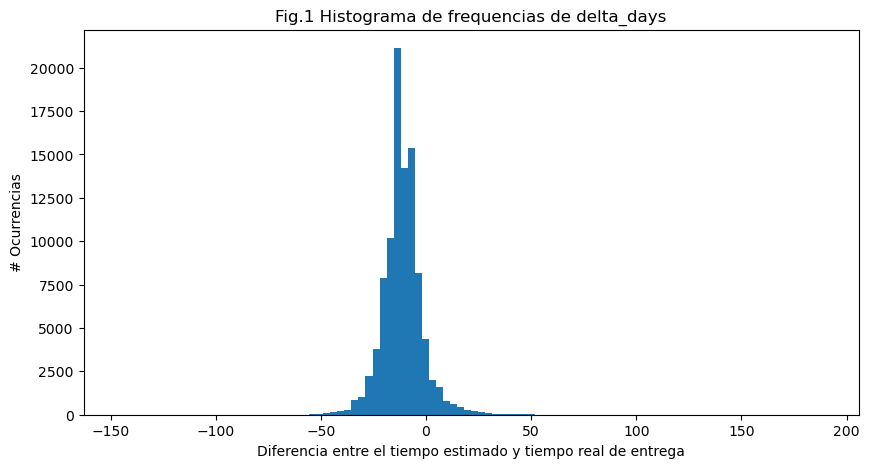

In [47]:
# figura y eje de la figura
fig, ax = plt.subplots(figsize=(10, 5))

# numero de intervalos para conteos
n_bins = 100

# creacion del objeto historgama
n, bins, patches = ax.hist(
    delivered['delta_days'],
    n_bins
    )

ax.set_title('Fig.1 Histograma de frequencias de delta_days')
ax.set_xlabel('Diferencia entre el tiempo estimado y tiempo real de entrega')
ax.set_ylabel('# Ocurrencias')

La gráfica anterior muestra la cantidad de veces que se observaron diferencias de tiempo entre la estimación y la entrega real. Como se aprencia hay pico alrededor del valor -11, porque como sabemos las órdenes tienden a llega antes de tiempo

Además, dicha gráfica está **sesgada a la izquierda**, antes del valor cero, lo que significa que la mayoria de las órdenes llegan antes del tiempo estimado. Los valores extremos  a la derecha indican retrasos, que como se ve pueden superar hasta los 50 días.

En estadística, existe un concepto denominado `regla empírica débil` que nos permite relacionar a la distribución de los datos junto con la media y la desviación estándar. En esencia, nos permite asegurar que aproximadamente 88.88% de los datos, se encontrarán entre el intervalo definido por la media y tres veces la desviación estándar.

Esto se puede constatar empíricamente en nuestro histograma, añadiendo las regiones descritan previamente:

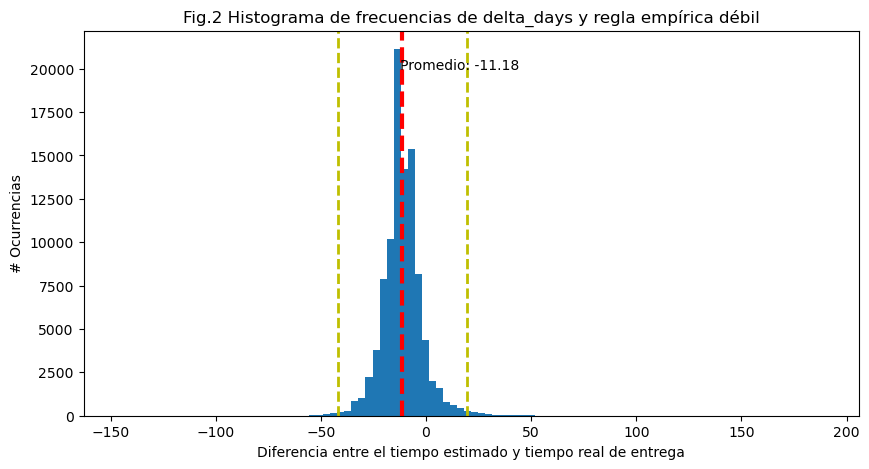

In [49]:
# figura y eje de la figura
fig, ax = plt.subplots(figsize=(10, 5))

# numero de intervalos para conteos
n_bins = 100

# creacion del objeto historgama
n, bins, patches = ax.hist(
    delivered['delta_days'],
    n_bins
    )

ax.set_title('Fig.2 Histograma de frecuencias de delta_days y regla empírica débil' )
ax.set_xlabel('Diferencia entre el tiempo estimado y tiempo real de entrega')
ax.set_ylabel('# Ocurrencias')

## Agrega la media y las regiones de la regla empírica débil
## Linea para la media
plt.axvline(
    oilst['delta_days'].mean(),
    color='r',
    linestyle='dashed',
    linewidth=3)

## Linea para la media + 3 veces la desv. estandar
plt.axvline(
    oilst['delta_days'].mean() + 3*oilst['delta_days'].std(),
    color='y',
    linestyle='dashed',
    linewidth=2)

## Linea para la media - 3 veces la desv. estandar
plt.axvline(
    oilst['delta_days'].mean() - 3*oilst['delta_days'].std(),
    color='y',
    linestyle='dashed',
    linewidth=2)

## limites de la figura
min_ylim, max_ylim = plt.ylim()

## Etiquetas
plt.text(
    delivered['delta_days'].mean()*1.1,
    max_ylim*0.9,
    'Promedio: {:.2f}'.format(oilst['delta_days'].mean())
    )

plt.show()

In [50]:
print("La mayoria de los datos se ubican en el intervalo:")

print(
    "(media + 3 desv. std , media - 3 desv. std)= ",'(',
    round(oilst['delta_days'].mean() - 3*oilst['delta_days'].std(),1), ",",
    round(oilst['delta_days'].mean() + 3*oilst['delta_days'].std(),1),")",
    )

La mayoria de los datos se ubican en el intervalo:
(media + 3 desv. std , media - 3 desv. std)=  ( -41.7 , 19.4 )


Una forma alternativa de visualizar lo anterior, es echar mano la **función de distribución acumulativa empírica**. 

Dicha herramienta es una manera de resumir datos y entender cómo se distribuyen los valores en un conjunto de datos, pues esencialmente, para una lista ordenada de números, nos permite entender cuántos de los valores son menores o iguales a un número específico y con ello entender de manera aproximada cuantos de los casos ocurren en la realidad y en que proporción, aproximando la probabilidad de un fenómeno.

Por ejemplo, si tenemos una lista de edades y queremos saber cuántas personas tienen 30 años o menos, 
podemos usar la función empírica de distribución cumulativa. Si hay 50 personas en total y 20 tienen 30 años o menos, entonces la función nos dirá que el 40% de las personas tienen 30 años o menos. Podemos repetir esto para cada edad y obtener una imagen completa de cómo se distribuyen las edades en nuestro conjunto de datos.

En el caso de la variable `delta_days`, la **función de distribución acumulativa empírica** se puede visualizar mediante la función `ecdfplot`. En el **eje X** se tiene el valor de la variable en estudio y en el **eje Y** se encuentra la proporción de casos que corresponden a valores menores o iguales a los del **eje X** .

En Python, se puede construir la función **función de distribución acumulativa empírica** usando las utilidades de Matplotlib `.hist` (https://www.google.com/search?client=safari&rls=en&q=hist+matplotlib&ie=UTF-8&oe=UTF-8) junto con sus parámetros `cumulative=True`, `histtype='step'` y ` density=True`

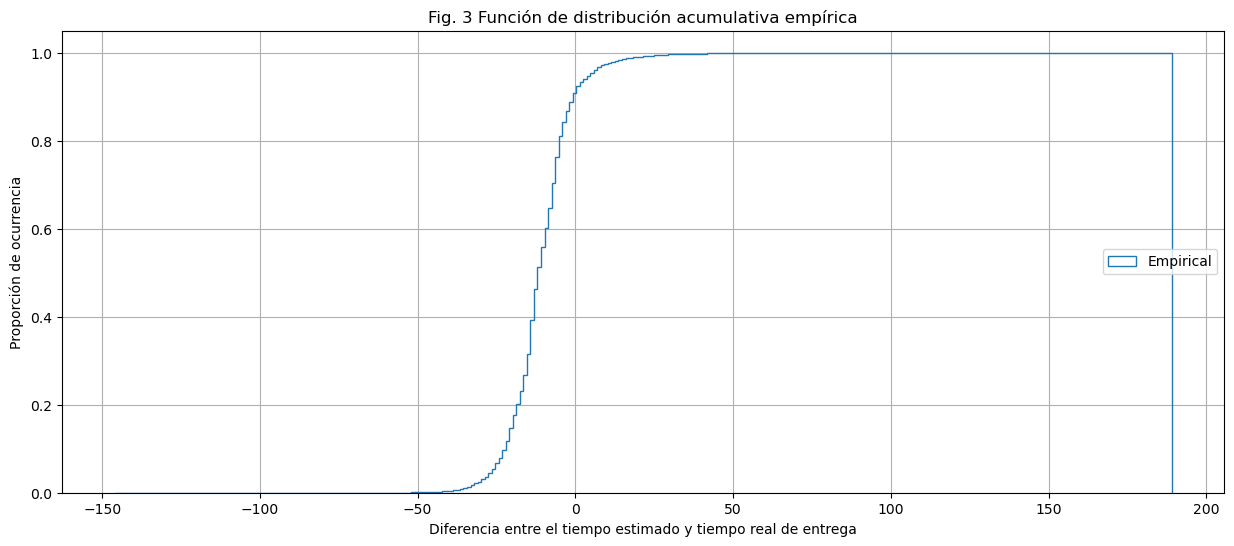

In [51]:
fig, ax = plt.subplots(figsize=(15, 6))

n_bins = 300

# plot the cumulative histogram
n, bins, patches = ax.hist(
    oilst.query("year > 2017")['delta_days'],
    n_bins,
    density=True,
    histtype='step',
    cumulative=True,
    label='Empirical'
    )

# tidy up the figure
ax.grid(True)
ax.legend(loc='right')
ax.set_title('Fig. 3 Función de distribución acumulativa empírica')
ax.set_xlabel('Diferencia entre el tiempo estimado y tiempo real de entrega')
ax.set_ylabel('Proporción de ocurrencia')

plt.show()

En esta gráfica se puede apreciar que casi con más del 90% de probabilidad, las órdenes llegan en tiempo (coimparando el valor cero en el eje X vs la proporción de ocurrencias en el eje Y).

Existe un concepto matemático llamda kernel gaussiano que permite aproximar dicha probabilidad y que en Python se calcula con la herramien `gaussian_kde` de la librería Scipy.

A continuación se aproximarán los valores que vemos en el diagrama de la función de distribución acumulativa empírica

In [52]:
# Aproxima los valores de la función de
#  distribución acumulativa empírica
import scipy.stats

# Nota: el metodo .dropna() elimina valores nulos
kde = scipy.stats.gaussian_kde(
    oilst['delta_days'].dropna() 
    )

Ahora estamos en condiciones de aproximar la probabilidad de recibir un pedido antes del tiempo estimado:

In [53]:
# Probabilidad de recibir entre un mes y hasta 
# en cero dias antes de lo estimado
print("Probabilidad: ",kde.integrate_box_1d(-30, 0)*100)

Probabilidad:  89.06667126779072


Del mismo modo, se puede calcular la probabilidad de recibir el pedio con retrazo moderado (entre cero dias de lo estimado y hasta en menos de 3):

In [54]:
# Probabilidad de recibir con un retraso moderado
print("Probabilidad: ",kde.integrate_box_1d(0, 3)*100)

Probabilidad:  2.995877169256003


**Pregunta:**

* ¿Cuál es la probabilidad de recibir un pedido entre 3 y 7 dias después de lo estimado?
* ¿Cuál es la probabilidad de recibir un pedido entre 3 y 15 dias después de lo estimado?
* ¿Cuál es la probabilidad de recibir un pedido después de 3 dias después de lo estimado? Hint: se puede usar una fecha muy larga como limite superior derecho, por ejemplo 200 días

**Respuesta:**
Código para cada cálculo:

kde.integrate_box_1d(3, 7)   * 100  # → 1.97%

kde.integrate_box_1d(3, 15)  * 100  # → 4.04%

kde.integrate_box_1d(3, 200) * 100  # → 5.52%


Interpretación: Solo el 5.52% de los pedidos llegan con más de 3 días de retraso, y de ese total, el 73% llega antes de los 15 días adicionales. Existe un grupo pequeño pero significativo (1.48%) con retrasos extremos que superan los 15 días


### 4.7 Análsis de correlación lineal

La correlación lineal es una herramienta que se utiliza para analizar la relación lineal entre varias variables. En esencia, lo que hace es medir cuánto se parecen dos variables y cuánto se influyen mutuamente.

Formalmente, se denomina **Coeficiente de correlación de Pearson** y se calcula como un coeficiente entre dos variables numéricas, que oscila entre entre -1 y 1, donde -1 significa que las dos variables están completamente inversamente relacionadas (si una aumenta, la otra disminuye) y 1 significa que las dos variables están completamente relacionadas (si una aumenta, la otra también lo hace). En el caso cercano a cero, esto significa que no hay correlacion de tipo lineal entre estas

Si queremos detectar que una variable tiene correlación lineal con otrra, su coeficiente de correlación debe aproximarse lo más posible a -1 o 1. 

Debemos mencionar que la existenciade correlación lineal entre dos variables no implica que una cause a la otra; por ejemplo, la cantidad de helados que se venden en verano aumenta a la vez que la cantidad de quemaduras en la piel en la misma época, sin que alguna de ellas sea la causa de la otra. Sin embargo la correlación alta es un elemento deseable en cualquier análisis exploratorio para comenzar a indagar como es que un fenómeno cambia ante diversos factores. 



Ahora veremos como cambia la distancia de los domicilios de los clientes a su centro de distribución más cercano (`distance_distribution_center`) con respecto al estatus del tiempo de entrega. Primero, podemos revisar los estadísticos básicos:

In [55]:
delivered.groupby(['delay_status'])['distance_distribution_center'].describe()

,count,mean,std,min,25%,50%,75%,max
delay_status,,,,,,,,
long_delay,5164.0,6415.812481,56385.831066,6.52,41.405,141.95,782.2275,1349721.75
on_time,88644.0,50.509725,29.120090,0.01,25.230,50.62,75.6400,101.00
short_delay,2662.0,2.647070,1.559544,1.00,1.580,2.01,2.9700,7.29


Ahora usaremos el métod `.corr` de pandas sobre las variables numéricas `total_sales`, `total_products`, `distance_distribution_center`y `delta_days`.

In [56]:
delivered[
    ['total_sales', 'total_products', 'distance_distribution_center', 'delta_days']
    ].corr().round(4)

,total_sales,total_products,distance_distribution_center,delta_days
total_sales,1.0000,0.1535,0.0069,-0.0136
total_products,0.1535,1.0000,-0.0024,-0.0320
distance_distribution_center,0.0069,-0.0024,1.0000,0.3312
delta_days,-0.0136,-0.0320,0.3312,1.0000


En esta tabla no se aprecia correlación entre las variables. Repitamos los cálculos pero en el caso de que ordenes entregas, que presentaron retrazos prolongados. 

In [57]:
filter_long = "delay_status == 'long_delay'"

numerical_variables = ['total_sales', 'total_products', 'distance_distribution_center', 'delta_days']

delivered.query(filter_long)[
    numerical_variables
    ].corr().round(4)


,total_sales,total_products,distance_distribution_center,delta_days
total_sales,1.0000,0.0756,0.0179,0.0187
total_products,0.0756,1.0000,-0.0035,-0.0179
distance_distribution_center,0.0179,-0.0035,1.0000,0.7609
delta_days,0.0187,-0.0179,0.7609,1.0000


**Preguntas**

* ¿Existe correlación fuerte entre alguna de las variables? De ser el caso, ¿entre cuales?
* ¿Qué es lo que implica lo anterior para el problema de los retrazos prolongados en las entregas a los clientes de Oilst?

**Respuesta:**
Hallazgo principal: correlación alta entre distance_distribution_center y delta_days (r = 0.76)

Esto significa que las órdenes con mayor distancia al centro de distribución más cercano tienden a tener retrasos más prolongados. Esta es la correlación más fuerte y estadísticamente significativa del análisis.

¿Qué implica para el problema de retrasos?

•	La distancia logística (last-mile delivery) es el factor determinante de los retrasos prolongados, no el valor de la compra ni la cantidad de productos

•	Los clientes en zonas remotas o alejadas de los centros de distribución son sistemáticamente los más perjudicados

•	La solución estructural no es operativa (más personal, más camiones) sino estratégica: expansión de la red de centros de distribución o alianzas con operadores logísticos locales en zonas con alta densidad de retrasos

Nota: Para retrasos >10 días, la correlación sube a r = 0.83, confirmando que el efecto de la distancia es aún más pronunciado en los casos extremos.


## 5. Entregables

En esta sección los entregables consisten en un script en Python junto con un tabla/imagen en un archivo en formato específico:

A. Script que calcule la proporción que han representado las ventas de órdenes completas de Oilst dentro de los categorías de `delay_status` y a los largo de los trimestres de 2016 a 2018. El resultado de este script deberá ser un tabla denominada `prop_sales_delay_status_by_quarte.csv`.

B. Programa que construya una tabla con la cantidad conteos cuantas órdenes que existieron por cantidad de productos dentro de la orden y el tipo de retraso de las categorías `delay_status`. El resultado de este script deberá ser un tabla denominada `count_orders_basket_size_by_delay_status.csv`.

C. Programa que construya el histograma de frecuencias de la variable `total_sales`, junto con la el promedio intervalos que define la regla empírica débil para encontrar el 88.88% de los datos alrededor del promedio, restringiendo el análisis las órdenes que tienen status completo. El resultado de este script deberá ser una figura denominada `histogram_sales_long_delay.png`.

D. Script que calcula la matriz de correlación entre las variables `total_sales`, `total_products`, `delta_days` y `distance_distribution_center` para órdenes completadas que cuya fecha de entrega sobrepasa los 10 días de la fecha estimada para la entrega.